# Spotify Popularity Analysis

My project focuses on analyzing and predicting song popularity on Spotify using audio features like danceability, energy, and loudness.

I first clean the dataset and explore patterns in popularity. Then I build regression models to predict the popularity score and classification models to identify highly popular songs. I also compare model results and feature importance to understand which variables are more useful.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme()
pd.set_option("display.max_columns", 100)

## 1. Load the dataset

The code below tries a few common file locations so the notebook can still run even if the folder structure changes.

In [2]:
# Load dataset into a pandas DataFrame
df = pd.read_csv("../data/dataset.csv")
df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Initial inspection

Before cleaning, inspect the shape, columns, data types, and summary statistics.

In [3]:
# Check the size of the dataset
print("Shape:", df.shape)

# Print all column names
print("\nColumns:")
print(df.columns.tolist())

# Check data types for each column
print("\nData types:")
display(df.dtypes)

# Show summary statistics for both numeric and categorical columns
display(df.describe(include="all").T.head(25))


Shape: (114000, 21)

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data types:


Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


## 3. Data cleaning

According to the proposal, the dataset should be cleaned by:
- removing the unnecessary index column,
- checking missing values,
- removing duplicates,
- converting categorical values into numeric format.

This helps ensure that the later analysis and models are based on consistent data.


In [4]:
# Drop the unnecessary index column if it exists
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Check missing values before cleaning
missing_before = df.isnull().sum().sort_values(ascending=False)

# Check duplicate rows before cleaning
duplicates_before = df.duplicated().sum()

print("Top missing-value counts before cleaning:")
display(missing_before[missing_before > 0].head(10))
print("Duplicate rows before cleaning:", duplicates_before)

# Remove rows with missing values and duplicate rows
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Convert boolean column to integer so models can use it directly
df["explicit"] = df["explicit"].astype(int)

# Encode genre as a numeric column for later models
# The original track_genre column is text, so models cannot use it directly.
genre_encoder = LabelEncoder()
df["track_genre_code"] = genre_encoder.fit_transform(df["track_genre"])

print("\nShape after cleaning:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

print("\nData types after cleaning:")
display(df.dtypes)


Top missing-value counts before cleaning:


album_name    1
track_name    1
artists       1
dtype: int64

Duplicate rows before cleaning: 450

Shape after cleaning: (113549, 21)
Duplicate rows after cleaning: 0

Data types after cleaning:


track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
track_genre_code      int64
dtype: object

After cleaning, the dataset is more consistent and easier to use for modeling. Dropping missing values and duplicates helps reduce noise, and encoding categorical variables allows the model to use genre information instead of ignoring it.

## 4. Basic overview of the target variable

Popularity is the main target in this project. Start by looking at its distribution.

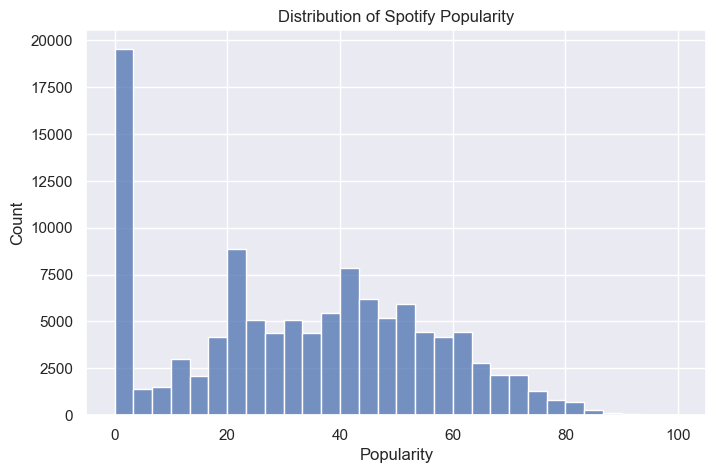

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [5]:
plt.figure(figsize=(8, 5))

# Plot distribution of popularity
sns.histplot(df["popularity"], bins=30)

# Add labels and title
plt.title("Distribution of Spotify Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

# Print summary statistics for popularity
print(df["popularity"].describe())


This histogram shows the distribution of Spotify popularity scores.

Most songs are concentrated in the low-to-medium popularity range, while very high popularity songs are much less common. This means the dataset is not evenly distributed across popularity levels. Because of this, predicting very popular songs can be harder than predicting average songs.

## 5. Quick genre overview

Genre is an important variable. A simple first look is to compare the average popularity of the most common genres.

,count,mean
track_genre,,
emo,1000,48.128
mandopop,1000,45.025
electronic,1000,44.325
pagode,1000,44.298
metalcore,1000,43.477
acoustic,1000,42.483
garage,1000,40.933
mpb,1000,40.792
punk-rock,1000,38.236


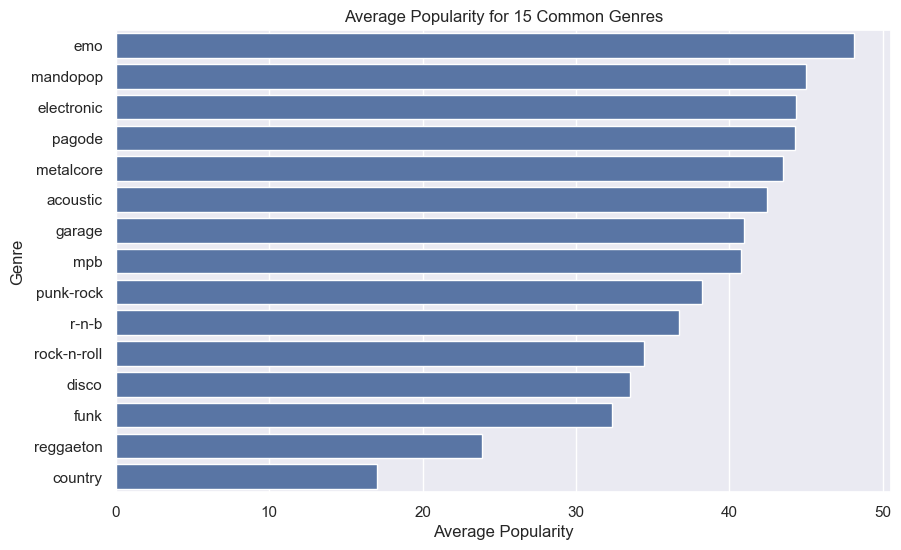

In [6]:
# Select the 15 most common genres to keep the plot readable
top_genres = df["track_genre"].value_counts().head(15).index

# Calculate count and average popularity for these genres
genre_summary = (
    df[df["track_genre"].isin(top_genres)]
    .groupby("track_genre")["popularity"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

# Display genre summary table
display(genre_summary)

plt.figure(figsize=(10, 6))

# Compare average popularity across common genres
sns.barplot(
    data=genre_summary.reset_index(),
    x="mean",
    y="track_genre"
)

plt.title("Average Popularity for 15 Common Genres")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()


This bar chart compares the average popularity of the most common genres.

Some genres have slightly higher average popularity than others, but the gap is not extremely large. This suggests that genre may help the model, but genre alone is not enough to explain popularity.

## 6. Correlation analysis

A correlation heatmap is a good first step for seeing linear relationships among numeric features.

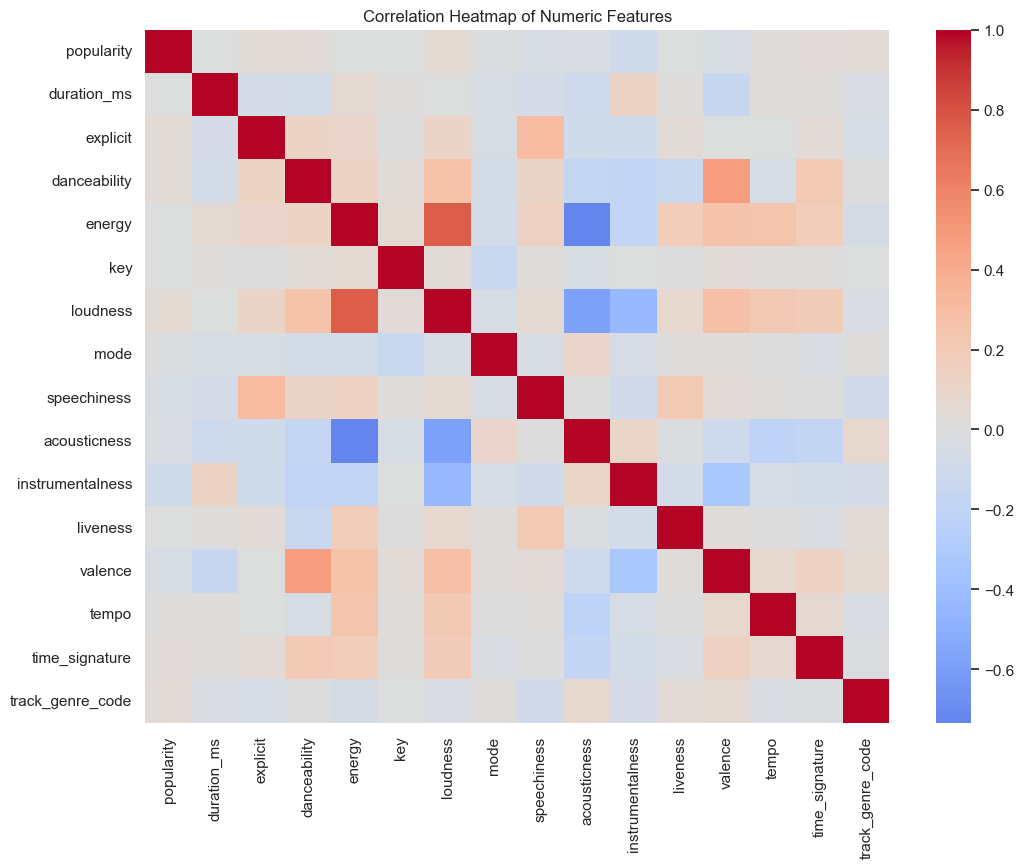

popularity          1.000000
loudness            0.047368
explicit            0.043938
danceability        0.034407
track_genre_code    0.032819
time_signature      0.030567
tempo               0.012187
energy             -0.002447
key                -0.004167
liveness           -0.005668
duration_ms        -0.007928
mode               -0.015009
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

In [7]:
# Keep only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 9))

# Visualize correlations between numeric features
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Sort correlations with popularity to identify strongest linear relationships
corr_with_popularity = numeric_df.corr()["popularity"].sort_values(ascending=False)
display(corr_with_popularity)


This heatmap shows the correlation between numerical features.

The correlation between most audio features and popularity is weak, which means there is no single feature that strongly explains popularity by itself. However, some features are correlated with each other, such as energy and loudness. This is useful because it shows that the model may need to combine multiple features instead of relying on one variable.

## 7. Feature engineering

I create a few simple engineered features:

- `log_duration`: a log transform of song length,
- `energy_loudness`: an interaction feature,
- `is_popular`: a binary label for classification (`popularity >= 70`).


In [8]:
# Log-transform duration to reduce the effect of very long songs
df["log_duration"] = np.log1p(df["duration_ms"])

# Create an interaction feature between energy and loudness
df["energy_loudness"] = df["energy"] * df["loudness"]

# Create a binary classification target
# A song is considered popular if popularity is at least 70.
df["is_popular"] = (df["popularity"] >= 70).astype(int)

# Display the new engineered features
display(df[["duration_ms", "log_duration", "energy", "loudness", "energy_loudness", "is_popular"]].head())

# Check class balance for the classification target
print("Class balance for is_popular:")
display(df["is_popular"].value_counts(normalize=True).rename("proportion"))


,duration_ms,log_duration,energy,loudness,energy_loudness,is_popular
0,230666,12.348730,0.4610,-6.746,-3.109906,1
1,149610,11.915794,0.1660,-17.235,-2.861010,0
2,210826,12.258793,0.3590,-9.734,-3.494506,0
3,201933,12.215696,0.0596,-18.515,-1.103494,1
4,198853,12.200326,0.4430,-9.681,-4.288683,1


Class balance for is_popular:


is_popular
0    0.951845
1    0.048155
Name: proportion, dtype: float64

These engineered features are added to give the models more information.

For example, `log_duration` reduces the effect of extremely long songs, and `energy_loudness` captures the combined effect of two related audio features. The `is_popular` label also prepares the dataset for the classification task.

## 8. Prepare features for modeling

For the first round of models, use:
- core audio features,
- a few engineered features,
- encoded genre.

Text metadata columns such as track name and artist are excluded because they are too detailed and noisy for these baseline models.


In [9]:
# Select audio features, engineered features, and encoded genre for modeling
feature_cols = [
    "duration_ms", "explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature", "track_genre_code",
    "log_duration", "energy_loudness"
]

# Build feature matrix and targets
X = df[feature_cols].copy()
y_reg = df["popularity"]
y_clf = df["is_popular"]

# Split data before scaling to avoid data leakage
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Use stratify for classification so train/test keep similar class proportions
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale features so large-value columns like duration_ms do not dominate linear models
# Fit the scaler only on training data, then transform both train and test data
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Regression feature matrix shape:", X.shape)
print("Classification target distribution:")
display(y_clf.value_counts(normalize=True).rename("proportion"))


Regression feature matrix shape: (113549, 17)
Classification target distribution:


is_popular
0    0.951845
1    0.048155
Name: proportion, dtype: float64

At this point, I separate the selected features from the target variable.

For regression, the target is the original popularity score. For classification, the target is the new `is_popular` variable. I also split the data into training and testing sets so the models can be evaluated on data they have not seen before.

## 9. Regression task: predict popularity

Two models are compared:

- Linear Regression as a baseline,
- Random Forest Regressor as a nonlinear model.

The linear model uses the scaled features, while the random forest can use the original feature values.


In [10]:
# Initialize Linear Regression as a simple baseline model
lin_reg = LinearRegression()

# Train the linear model using scaled features
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# Predict popularity scores on the test set
y_pred_lin = lin_reg.predict(X_test_reg_scaled)

# Calculate RMSE to measure average prediction error
lin_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))

# Calculate R-squared to measure explained variance
lin_r2 = r2_score(y_test_reg, y_pred_lin)

# Initialize Random Forest Regressor as a nonlinear model
rf_reg = RandomForestRegressor(
    n_estimators=120,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model on the original feature values
rf_reg.fit(X_train_reg, y_train_reg)

# Predict popularity scores on the test set
y_pred_rf = rf_reg.predict(X_test_reg)

# Calculate RMSE for Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))

# Calculate R-squared for Random Forest
rf_r2 = r2_score(y_test_reg, y_pred_rf)

# Compare regression model performance in one table
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [lin_rmse, rf_rmse],
    "R2": [lin_r2, rf_r2]
})

display(regression_results)


,Model,RMSE,R2
0,Linear Regression,22.084161,0.027718
1,Random Forest Regressor,16.430692,0.461802


The regression results compare a simple linear model with a nonlinear Random Forest model.

The Linear Regression model acts as a baseline. If Random Forest performs better, it suggests that the relationship between audio features and popularity is not purely linear. However, if both models have limited performance, it means popularity is influenced by other factors beyond the features in this dataset.

## 10. Regression diagnostics

Besides plotting actual vs predicted values, I also check the residuals. Residuals are the difference between the actual popularity score and the predicted score. If the residuals are centered around 0 without a strong pattern, the model is doing a reasonable job capturing the main trend.


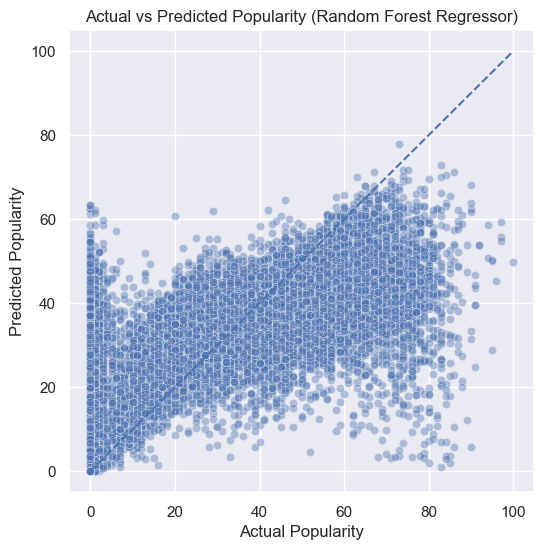

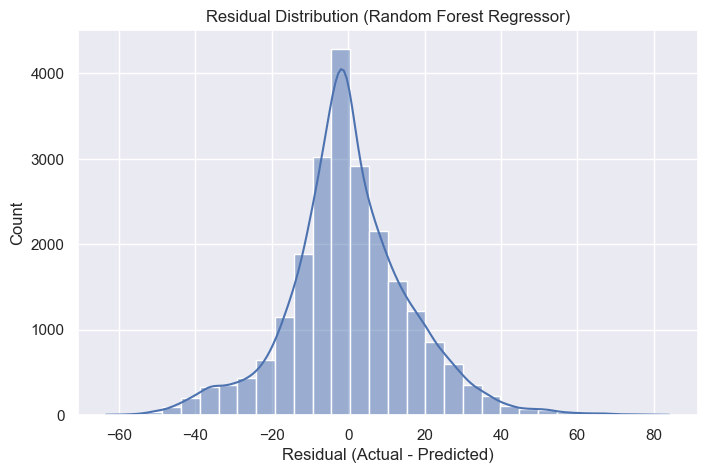

In [11]:
# Choose the model with lower RMSE as the best regression model
best_reg_name = regression_results.sort_values("RMSE").iloc[0]["Model"]
best_preds = y_pred_rf if best_reg_name == "Random Forest Regressor" else y_pred_lin

plt.figure(figsize=(6, 6))

# Compare actual popularity with predicted popularity
sns.scatterplot(x=y_test_reg, y=best_preds, alpha=0.4)

# Add reference line where prediction equals actual value
plt.plot([0, 100], [0, 100], linestyle="--")

plt.title(f"Actual vs Predicted Popularity ({best_reg_name})")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.show()

# Residual analysis: actual value minus predicted value
residuals = y_test_reg - best_preds

plt.figure(figsize=(8, 5))

# Plot residual distribution to check prediction errors
sns.histplot(residuals, bins=30, kde=True)

plt.title(f"Residual Distribution ({best_reg_name})")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


The actual vs predicted plot shows how close the model predictions are to the real popularity values.

Ideally, the points should be close to the diagonal line. In this case, the points are spread out, which means the model can capture some general patterns but still makes many errors. The residual plot shows the prediction errors. If residuals are centered around zero, the model is not strongly biased, but a wide spread still means the predictions are not very accurate.

## 11. Classification Modeling (Goal 3: Predict High Popularity)

I first use Logistic Regression as a simple baseline classification model, then try Random Forest Classifier as a stronger nonlinear model. Since popular songs are less common than regular songs, I focus on F1-score in addition to accuracy.


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     21616
           1       0.00      0.00      0.00      1094

    accuracy                           0.95     22710
   macro avg       0.48      0.50      0.49     22710
weighted avg       0.91      0.95      0.93     22710



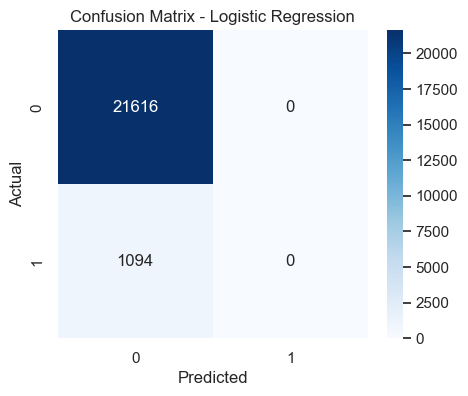

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     21616
           1       0.98      0.10      0.17      1094

    accuracy                           0.96     22710
   macro avg       0.97      0.55      0.58     22710
weighted avg       0.96      0.96      0.94     22710



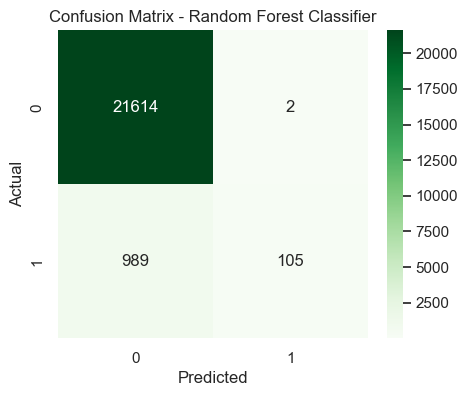

In [12]:
# Initialize Logistic Regression as a baseline classification model
log_clf = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using scaled classification features
log_clf.fit(X_train_clf_scaled, y_train_clf)

# Predict whether songs are popular
y_pred_log = log_clf.predict(X_test_clf_scaled)

# Evaluate baseline classification performance
print("Classification Report for Logistic Regression:")
print(classification_report(y_test_clf, y_pred_log))

# Plot confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test_clf, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Train a nonlinear classifier for comparison
rf_clf = RandomForestClassifier(
    n_estimators=120,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Random Forest does not require scaled features
rf_clf.fit(X_train_clf, y_train_clf)

# Predict with Random Forest classifier
y_pred_rf_clf = rf_clf.predict(X_test_clf)

# Evaluate Random Forest classification performance
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test_clf, y_pred_rf_clf))

# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_clf, y_pred_rf_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The classification results show how well the models identify popular songs.

Accuracy gives a general idea of performance, but because the dataset is imbalanced, precision, recall, and F1-score are also important. A model can have decent accuracy while still missing many popular songs, so the confusion matrix and classification report give a better understanding of the result.

## 12. Handling class imbalance and tuning the classifier

Since the `is_popular` target is likely imbalanced, I also try SMOTE to balance the training data. After that, I tune the Random Forest classifier with GridSearchCV and evaluate the model using a Precision-Recall curve.

This is useful because accuracy alone can be misleading when there are fewer popular songs than non-popular songs.


In [ ]:
# Import SMOTE for oversampling the minority class
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf, y_train_clf)

# Check class distribution before SMOTE
print("Before SMOTE:")
print(y_train_clf.value_counts())

# Check class distribution after SMOTE
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
is_popular
0    86465
1     4374
Name: count, dtype: int64

After SMOTE:
is_popular
0    86465
1    86465
Name: count, dtype: int64


Classification Report for Random Forest with SMOTE:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     21616
           1       0.20      0.62      0.30      1094

    accuracy                           0.86     22710
   macro avg       0.59      0.75      0.61     22710
weighted avg       0.94      0.86      0.89     22710



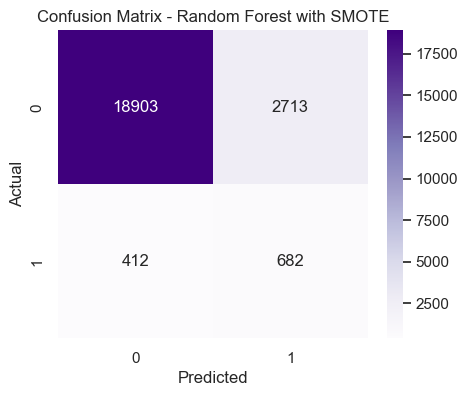

In [14]:
# Train Random Forest again using the balanced SMOTE training data
rf_smote = RandomForestClassifier(
    n_estimators=120,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model on oversampled training data
rf_smote.fit(X_train_smote, y_train_smote)

# Predict on the original test set
y_pred_smote = rf_smote.predict(X_test_clf)

# Evaluate the SMOTE model
print("Classification Report for Random Forest with SMOTE:")
print(classification_report(y_test_clf, y_pred_smote))

# Plot confusion matrix for SMOTE model
cm_smote = confusion_matrix(y_test_clf, y_pred_smote)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Random Forest with SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


After applying SMOTE, I train the Random Forest classifier again.

The goal is to see whether balancing the classes improves the model’s ability to identify popular songs. This may improve recall, but it can also reduce precision, so the tradeoff needs to be evaluated carefully.

In [15]:
# Tune Random Forest hyperparameters using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define a small parameter grid to keep runtime reasonable
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2]
}

# Use F1 score because the classification target is imbalanced
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Fit grid search on the SMOTE-balanced training data
grid.fit(X_train_smote, y_train_smote)

# Print the best hyperparameters
print("Best Parameters:")
print(grid.best_params_)

# Use the best model from grid search
best_rf = grid.best_estimator_

# Predict on the original test set
y_pred_best = best_rf.predict(X_test_clf)

# Evaluate tuned Random Forest
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test_clf, y_pred_best))


Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     21616
           1       0.43      0.59      0.50      1094

    accuracy                           0.94     22710
   macro avg       0.71      0.77      0.74     22710
weighted avg       0.95      0.94      0.95     22710



GridSearchCV tests several combinations of Random Forest parameters and selects the best one based on validation performance.

This helps improve the classifier without manually guessing the best settings. However, tuning does not always guarantee a large improvement, especially when the available features have weak relationships with popularity.

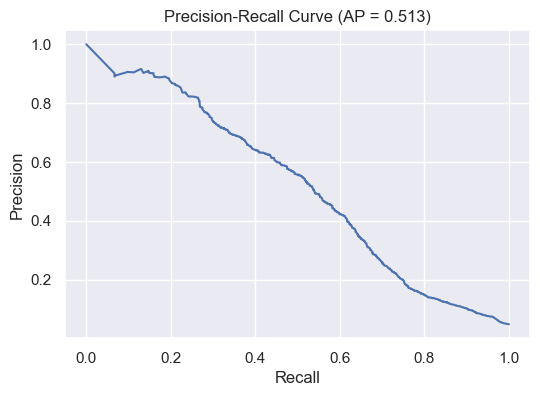

In [16]:
# Precision-Recall curve is useful for imbalanced classification
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities for the positive class
y_scores = best_rf.predict_proba(X_test_clf)[:, 1]

# Compute precision and recall across different thresholds
precision, recall, thresholds = precision_recall_curve(y_test_clf, y_scores)

# Calculate average precision as a summary score
avg_precision = average_precision_score(y_test_clf, y_scores)

plt.figure(figsize=(6, 4))

# Plot precision-recall tradeoff
plt.plot(recall, precision)

plt.title(f"Precision-Recall Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


The precision-recall curve is especially useful for this project because the popular-song class is imbalanced.

Average precision summarizes how well the model balances precision and recall across different thresholds. A better curve means the model is better at ranking songs by their likelihood of being popular.

Classification Report with threshold = 0.3:
              precision    recall  f1-score   support

           0       0.98      0.89      0.94     21616
           1       0.25      0.70      0.37      1094

    accuracy                           0.88     22710
   macro avg       0.62      0.80      0.65     22710
weighted avg       0.95      0.88      0.91     22710



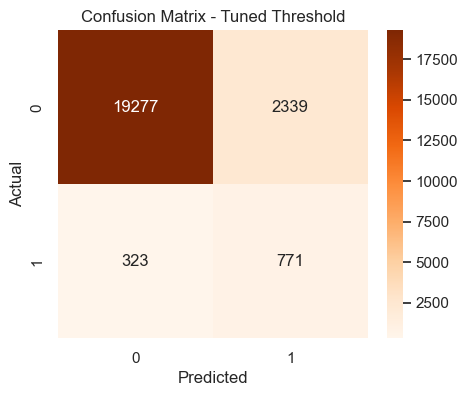

In [17]:
# Adjust the classification threshold to improve recall
threshold = 0.30

# Convert probabilities into class predictions using the custom threshold
y_pred_adjusted = (y_scores > threshold).astype(int)

# Evaluate threshold-adjusted predictions
print(f"Classification Report with threshold = {threshold}:")
print(classification_report(y_test_clf, y_pred_adjusted))

# Plot confusion matrix after threshold adjustment
cm_adjusted = confusion_matrix(y_test_clf, y_pred_adjusted)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_adjusted, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Tuned Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Lowering the classification threshold makes the model more willing to predict a song as popular.

This usually increases recall, meaning fewer popular songs are missed. However, it may also increase false positives, meaning some non-popular songs may be incorrectly labeled as popular.

## 13. Feature importance

Use Random Forest feature importance to see which variables contribute most to prediction. I also print the highest importance values so I can check whether one feature, such as `track_genre_code`, is dominating too much. If genre is highly important, it suggests that musical style and audience category are strongly related to popularity.


Top feature importance values:


track_genre_code    0.245973
acousticness        0.079201
danceability        0.072218
valence             0.069841
speechiness         0.064598
tempo               0.063770
energy              0.060767
energy_loudness     0.056418
loudness            0.055343
liveness            0.055096
instrumentalness    0.054047
duration_ms         0.040133
log_duration        0.040013
key                 0.026153
explicit            0.006587
dtype: float64

track_genre_code rank: 1
track_genre_code importance: 0.2460


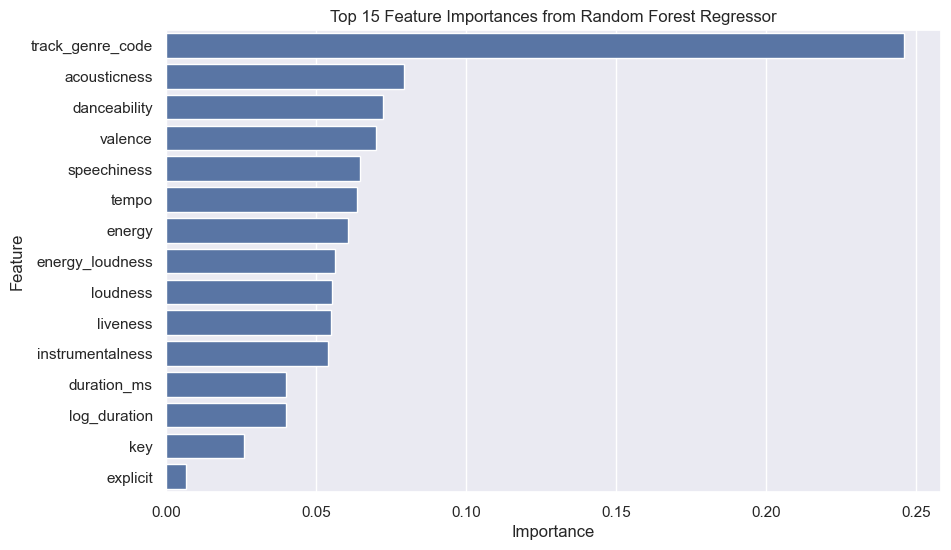

In [18]:
# Get feature importance from the trained Random Forest Regressor
rf_importance_all = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

# Keep only the top 15 features for a readable plot
rf_importance = rf_importance_all.head(15)

print("Top feature importance values:")
display(rf_importance)

# Check whether the encoded genre column is one of the strongest predictors
if "track_genre_code" in rf_importance_all.index:
    genre_rank = rf_importance_all.index.get_loc("track_genre_code") + 1
    genre_importance = rf_importance_all.loc["track_genre_code"]
    print(f"track_genre_code rank: {genre_rank}")
    print(f"track_genre_code importance: {genre_importance:.4f}")

plt.figure(figsize=(10, 6))

# Plot the top feature importances
sns.barplot(x=rf_importance.values, y=rf_importance.index)

plt.title("Top 15 Feature Importances from Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 14. Conclusion

Overall, this project shows that Spotify audio features can provide some insight into song popularity, but they are not enough to fully predict it.

The regression models show limited predictive power, which suggests that popularity is affected by external factors such as artist reputation, playlist placement, marketing, and social trends. The classification models are more useful for identifying whether a song is likely to be highly popular, especially after considering class imbalance and threshold adjustment.

In future work, I could improve the project by adding more features, such as artist-level popularity, release date, playlist data, and social media trends.